# 06 · Decision Framework

Everything so far leads to one practical question: *given a dataset, which detector should you actually use?* The answer begins by naming the kind of outlier that matters for your problem — then it is almost decided for you.

```
What kind of outlier matters?
├─ univariate, roughly symmetric      → IQR or modified z-score  (never plain three-sigma)
├─ multivariate vs one correlated cloud → Mahalanobis distance
├─ local, varying-density regions      → Local Outlier Factor (LOF)
├─ general tabular, mixed kinds        → Isolation Forest  (robust default)
└─ high dimensions                     → Isolation Forest; cut irrelevant features; avoid distance methods
```


In [1]:
%matplotlib inline
import sys
from pathlib import Path

_root = Path.cwd()
while _root != _root.parent and not (_root / "pyproject.toml").exists():
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.artifacts import save_figure, save_json

plt.rcParams["figure.dpi"] = 110
SEED = 7

from src.datasets.synthetic import make_dataset
from src.evaluation.comparison import detect_outliers
from src.evaluation.agreement import agreement_report

## 1 · The decision guide, as one picture

PosixPath('/workspaces/outlier_arena/outputs/data/06_decision_guide.json')

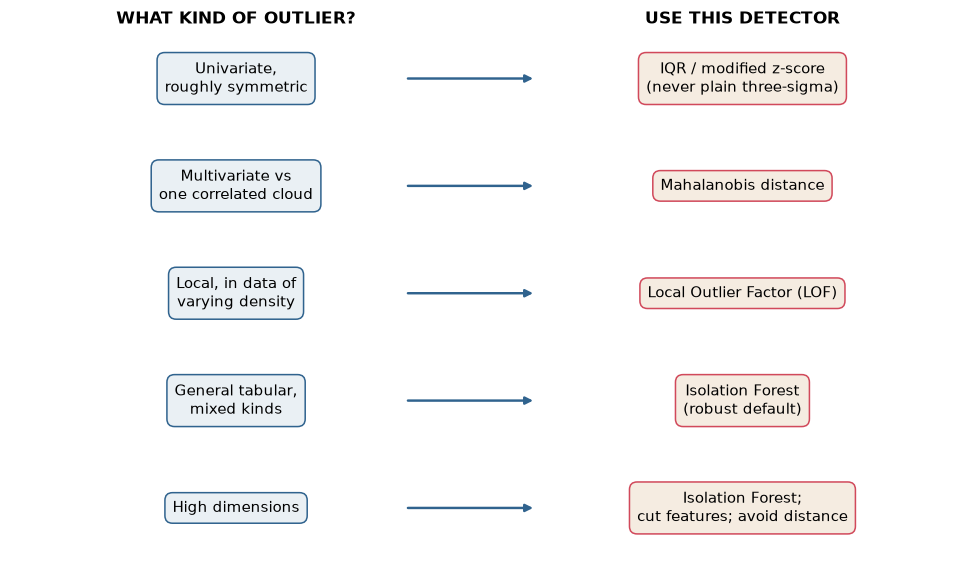

In [2]:
guide = [
    ("Univariate,\nroughly symmetric", "IQR / modified z-score\n(never plain three-sigma)"),
    ("Multivariate vs\none correlated cloud", "Mahalanobis distance"),
    ("Local, in data of\nvarying density", "Local Outlier Factor (LOF)"),
    ("General tabular,\nmixed kinds", "Isolation Forest\n(robust default)"),
    ("High dimensions", "Isolation Forest;\ncut features; avoid distance"),
]
fig, ax = plt.subplots(figsize=(11, 6.5))
ax.axis("off")
ax.set(xlim=(0, 1), ylim=(0, 1))
ys = np.linspace(0.88, 0.1, len(guide))
for (scen, rec), y in zip(guide, ys):
    ax.text(0.24, y, scen, ha="center", va="center", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.5", fc="#eaf0f4", ec="#30638e"))
    ax.annotate("", xy=(0.56, y), xytext=(0.42, y),
                arrowprops=dict(arrowstyle="-|>", color="#30638e", lw=1.6))
    ax.text(0.78, y, rec, ha="center", va="center", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.5", fc="#f5ece1", ec="#d1495b"))
ax.text(0.24, 0.98, "WHAT KIND OF OUTLIER?", ha="center", fontsize=11, weight="bold")
ax.text(0.78, 0.98, "USE THIS DETECTOR", ha="center", fontsize=11, weight="bold")
save_figure(fig, "06_decision_guide")

guide_records = [
    {"scenario": s.replace("\n", " "), "recommended": r.replace("\n", " ")}
    for s, r in guide
]
save_json({"decision_guide": guide_records}, "06_decision_guide")

## 2 · `detect_outliers(X, method, contamination)`

The shipped one-liner: flag outliers with any single named detector.

In [3]:
data = make_dataset(n_samples=600, n_features=2, contamination=0.08, seed=SEED)

flagged = {}
for method in ["iqr", "mahalanobis", "lof", "isolation_forest"]:
    mask = detect_outliers(data.X, method=method, contamination=0.08)
    flagged[method] = int(mask.sum())
print("points flagged by each detector:", flagged)
save_json({"inputs": {"n_samples": 600, "contamination": 0.08, "seed": SEED},
           "n_flagged_by_method": flagged}, "06_detect_outliers_demo")

points flagged by each detector: {'iqr': 16, 'mahalanobis': 48, 'lof': 48, 'isolation_forest': 48}


PosixPath('/workspaces/outlier_arena/outputs/data/06_detect_outliers_demo.json')

## 3 · `agreement_report(X)` — don't trust one verdict

The companion utility runs several detectors and surfaces exactly where they conflict, so you can see the disputed points instead of pretending one detector's answer is the truth.

In [4]:
report = agreement_report(data.X, contamination=0.08)
print(f"mean pairwise agreement : {report.mean_agreement:.1%}")
print(f"consensus among flagged : {report.consensus_fraction:.1%}")
print(f"disputed points         : {report.n_disputed} of {data.X.shape[0]}")
save_json({
    "mean_pairwise_agreement": report.mean_agreement,
    "consensus_fraction": report.consensus_fraction,
    "n_disputed": report.n_disputed,
    "names": report.names,
    "jaccard_matrix": report.jaccard_matrix,
}, "06_agreement_report")

mean pairwise agreement : 51.9%
consensus among flagged : 25.0%
disputed points         : 48 of 600


PosixPath('/workspaces/outlier_arena/outputs/data/06_agreement_report.json')

## Meta-rules

1. **Decide what kind of outlier matters before choosing a detector.** The choice is otherwise arbitrary, and the detectors genuinely disagree.
2. **Run more than one detector and inspect the disagreements** rather than trusting a single verdict.
3. **Removing outliers is a modeling decision** that changes what your model learns. It deserves more than a reflex — choose by anomaly type, prefer robust rules, and look at what you are about to throw away.

In [5]:
summary = {
    "notebook": "06_decision_framework",
    "decision_guide": guide_records,
    "detect_outliers_demo": flagged,
    "agreement_report": {
        "mean_pairwise_agreement": report.mean_agreement,
        "consensus_fraction": report.consensus_fraction,
        "n_disputed": report.n_disputed,
    },
    "meta_rules": [
        "Decide the anomaly type before choosing a detector.",
        "Run several detectors and inspect the disagreements.",
        "Treat outlier removal as a deliberate modeling decision.",
    ],
}
save_json(summary, "06_summary")
summary

{'notebook': '06_decision_framework',
 'decision_guide': [{'scenario': 'Univariate, roughly symmetric',
   'recommended': 'IQR / modified z-score (never plain three-sigma)'},
  {'scenario': 'Multivariate vs one correlated cloud',
   'recommended': 'Mahalanobis distance'},
  {'scenario': 'Local, in data of varying density',
   'recommended': 'Local Outlier Factor (LOF)'},
  {'scenario': 'General tabular, mixed kinds',
   'recommended': 'Isolation Forest (robust default)'},
  {'scenario': 'High dimensions',
   'recommended': 'Isolation Forest; cut features; avoid distance'}],
 'detect_outliers_demo': {'iqr': 16,
  'mahalanobis': 48,
  'lof': 48,
  'isolation_forest': 48},
 'agreement_report': {'mean_pairwise_agreement': 0.5186066420818888,
  'consensus_fraction': 0.25,
  'n_disputed': 48},
 'meta_rules': ['Decide the anomaly type before choosing a detector.',
  'Run several detectors and inspect the disagreements.',
  'Treat outlier removal as a deliberate modeling decision.']}